In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


In [2]:
data = pd.read_csv('dog_rates_tweets.csv')


In [3]:
data.head()

,id,created_at,text
0,994677639364403200,2018-05-10 20:36:44,@Steff88979267 tell them to h*ck off
1,994364904978239488,2018-05-09 23:54:02,@NFLOwnerGBP take it back
2,994363623421153280,2018-05-09 23:48:56,This is Louie. He has misplaced his Cheerio. W...
3,994336722875047936,2018-05-09 22:02:03,@rachaellanaghan ❤️
4,994024065982717952,2018-05-09 01:19:40,This is Captain Jack Wobbles. He is currently ...


In [4]:
data['rating'] = data['text'].str.extract(r'(\d+(\.\d+)?)/10')[0].astype(float)

In [5]:
data = data[ data['rating'].notnull()]
data.head()


,id,created_at,text,rating
2,994363623421153280,2018-05-09 23:48:56,This is Louie. He has misplaced his Cheerio. W...,14.0
7,993889039714578432,2018-05-08 16:23:07,This is Manny. He hasn’t seen your croissant. ...,13.0
8,993629544463642624,2018-05-07 23:11:58,This is Libby. She leap. 14/10\n(IG: libbythef...,14.0
24,992198572664860672,2018-05-04 00:25:48,This is Rosie. She thought Coachella was this ...,13.0
30,991744041351090177,2018-05-02 18:19:39,This is Riley. He’ll be your chauffeur this ev...,13.0


In [6]:
data = data[ data[ 'rating'] <= 25]

In [7]:
data.head()


,id,created_at,text,rating
2,994363623421153280,2018-05-09 23:48:56,This is Louie. He has misplaced his Cheerio. W...,14.0
7,993889039714578432,2018-05-08 16:23:07,This is Manny. He hasn’t seen your croissant. ...,13.0
8,993629544463642624,2018-05-07 23:11:58,This is Libby. She leap. 14/10\n(IG: libbythef...,14.0
24,992198572664860672,2018-05-04 00:25:48,This is Rosie. She thought Coachella was this ...,13.0
30,991744041351090177,2018-05-02 18:19:39,This is Riley. He’ll be your chauffeur this ev...,13.0


In [8]:
data['created_at'] = pd.to_datetime(data['created_at'], format='ISO8601', utc=True)

In [9]:
data.dtypes

id                          int64
created_at    datetime64[us, UTC]
text                          str
rating                    float64
dtype: object

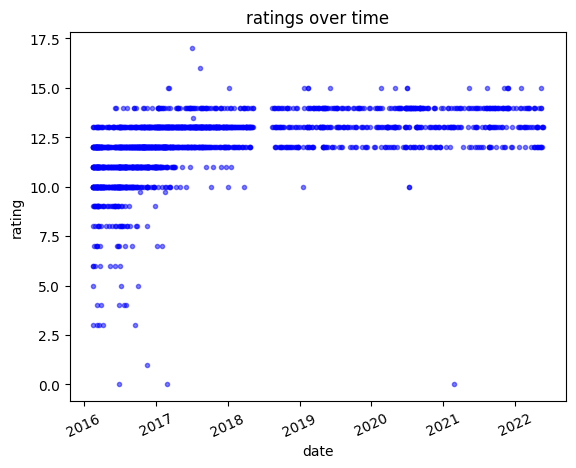

In [10]:

plt.plot(data['created_at'], data['rating'], 'b.', alpha=0.5)
plt.xticks(rotation=25)
plt.xlabel("date")
plt.ylabel("rating")
plt.title("ratings over time")
plt.show()

In [11]:
def to_timestamp(date):
    return date.timestamp()


In [12]:
data['timestamp'] = data['created_at'].apply(to_timestamp)

In [13]:
data.head()

,id,created_at,text,rating,timestamp
2,994363623421153280,2018-05-09 23:48:56+00:00,This is Louie. He has misplaced his Cheerio. W...,14.0,1.525910e+09
7,993889039714578432,2018-05-08 16:23:07+00:00,This is Manny. He hasn’t seen your croissant. ...,13.0,1.525797e+09
8,993629544463642624,2018-05-07 23:11:58+00:00,This is Libby. She leap. 14/10\n(IG: libbythef...,14.0,1.525735e+09
24,992198572664860672,2018-05-04 00:25:48+00:00,This is Rosie. She thought Coachella was this ...,13.0,1.525394e+09
30,991744041351090177,2018-05-02 18:19:39+00:00,This is Riley. He’ll be your chauffeur this ev...,13.0,1.525285e+09


In [14]:


fit = stats.linregress(data['timestamp'], data['rating'])
fit.slope, fit.intercept


(np.float64(1.5000503986105543e-08), np.float64(-10.585967528906664))

In [15]:

data['prediction'] = data['timestamp']*fit.slope + fit.intercept
data.head()

,id,created_at,text,rating,timestamp,prediction
2,994363623421153280,2018-05-09 23:48:56+00:00,This is Louie. He has misplaced his Cheerio. W...,14.0,1.525910e+09,12.303448
7,993889039714578432,2018-05-08 16:23:07+00:00,This is Manny. He hasn’t seen your croissant. ...,13.0,1.525797e+09,12.301750
8,993629544463642624,2018-05-07 23:11:58+00:00,This is Libby. She leap. 14/10\n(IG: libbythef...,14.0,1.525735e+09,12.300822
24,992198572664860672,2018-05-04 00:25:48+00:00,This is Rosie. She thought Coachella was this ...,13.0,1.525394e+09,12.295704
30,991744041351090177,2018-05-02 18:19:39+00:00,This is Riley. He’ll be your chauffeur this ev...,13.0,1.525285e+09,12.294079


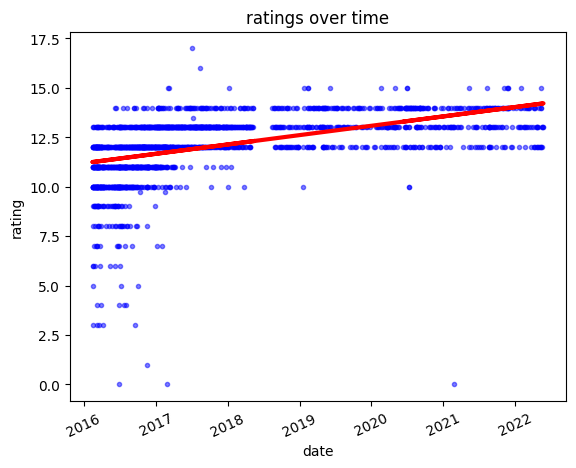

In [16]:
plt.xticks(rotation=25)
plt.plot(data['created_at'], data['rating'], 'b.', alpha=0.5)

plt.plot(data['created_at'], data['prediction'], 'r-', linewidth=3)

plt.xlabel('date')
plt.ylabel('rating')
plt.title('ratings over time')
plt.show()

In [17]:


data


,id,created_at,text,rating,timestamp,prediction
2,994363623421153280,2018-05-09 23:48:56+00:00,This is Louie. He has misplaced his Cheerio. W...,14.0,1.525910e+09,12.303448
7,993889039714578432,2018-05-08 16:23:07+00:00,This is Manny. He hasn’t seen your croissant. ...,13.0,1.525797e+09,12.301750
8,993629544463642624,2018-05-07 23:11:58+00:00,This is Libby. She leap. 14/10\n(IG: libbythef...,14.0,1.525735e+09,12.300822
24,992198572664860672,2018-05-04 00:25:48+00:00,This is Rosie. She thought Coachella was this ...,13.0,1.525394e+09,12.295704
30,991744041351090177,2018-05-02 18:19:39+00:00,This is Riley. He’ll be your chauffeur this ev...,13.0,1.525285e+09,12.294079
...,...,...,...,...,...,...
14885,1275493485085245440,2020-06-23 18:18:39+00:00,This is Ruth. She was spotted at a rally doing...,14.0,1.592936e+09,13.308880
14895,1275102054608855040,2020-06-22 16:23:14+00:00,This is Narcos. He is very angry with you. The...,13.0,1.592843e+09,13.307480
14896,1274821722584125442,2020-06-21 21:49:18+00:00,@PatrickKenneyMD omg i’d say 13/10 but i’d hat...,13.0,1.592776e+09,13.306478
14906,1273774320519483392,2020-06-19 00:27:18+00:00,This is Oakley. He’s on his way home for the f...,12.0,1.592526e+09,13.302732


In [18]:
fit.slope, fit.intercept

(np.float64(1.5000503986105543e-08), np.float64(-10.585967528906664))

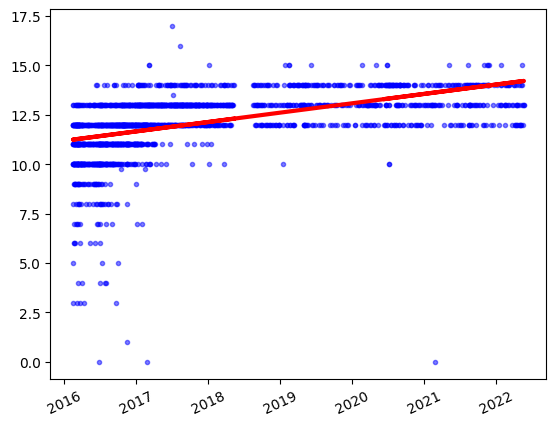

In [19]:
plt.xticks(rotation=25)
plt.plot(data['created_at'], data['rating'], 'b.', alpha=0.5)
plt.plot(data['created_at'], data['prediction'], 'r-', linewidth=3)
plt.show()

In [20]:
fit.pvalue


np.float64(2.6070388139665127e-127)

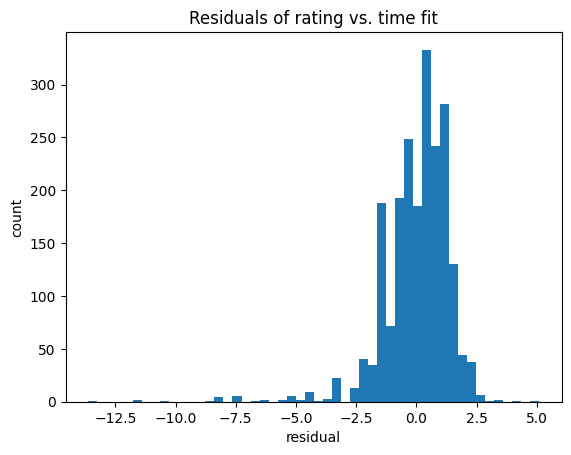

In [21]:
residuals = data['rating'] - data['prediction']
plt.hist(residuals, bins=50)
plt.xlabel('residual')
plt.ylabel('count')
plt.title('Residuals of rating vs. time fit')
plt.show()